In [1]:
import numpy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from omegaconf import OmegaConf
import json
import os
__DIR__ = os.path.dirname("../")
import sys
sys.path.append(__DIR__)
from datasets import load_from_disk, concatenate_datasets
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
import plotly.graph_objects as go
import matplotlib.cm as cm
from copy import deepcopy
import seaborn as sns
import matplotlib.cm as cm
from diff_masking.utils.phi3 import create_masked_phi
torch.cuda.set_device(0)  # Replace 1 with the desired CUDA device index

In [63]:
checkpoint = "2024-10-28_17-00-51"
checkpoint_path = os.path.join("../outputs/main/", checkpoint)

# Loading the model

In [3]:
model_name = "microsoft/Phi-3-mini-128k-instruct"
model = AutoModelForCausalLM.from_pretrained( 
            model_name,  
            device_map="cuda:0",  
            torch_dtype=torch.bfloat16,  
            trust_remote_code=True,  
            attn_implementation="flash_attention_2"
) 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
model_config = model.config

In [64]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [6]:
with open(checkpoint_path+"/config.json", 'r') as file:
    config_dict = json.load(file)

In [7]:
config = OmegaConf.create(config_dict)
masking = config.masking if "masking" in config else "probabilistic"

In [8]:
model = create_masked_phi(model, config.specs.target_layers, config.specs.init_prob, config.specs.tau, checkpoint_path+"/model.pth", masking=masking)

/media/data/nicolas/project/mechanisms/KG_networks/notebooks/../diff_masking/utils/phi3.py:384: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mask_parameters = torch.load(ch

In [9]:
model.cuda()
torch.cuda.empty_cache()

# Exploring the masked densities

In [10]:
layer_weights = {}
for name, param in model.named_parameters():
    if "mask" in name:
        layer_weights[name] = param.detach()

In [11]:
def get_mask(mask_param, tau, training, binary=True):
    if training:
        U1 = torch.rand_like(mask_param).requires_grad_(False)
        U1 += (U1<=1e-12)*1e-12
        U2 = torch.rand_like(mask_param).requires_grad_(False)
        U2 += (U2<=1e-12)*1e-12
        mask = F.sigmoid((mask_param-torch.log(torch.log(U1)/torch.log(U2))) / tau)
    else:
        mask = F.sigmoid(mask_param / tau)
    if binary:
        return (mask>0.5).int() 
    else:
        return mask

## Overal densities

Text(0.5, 1.0, '2D Histogram of Real valued mask parameters')

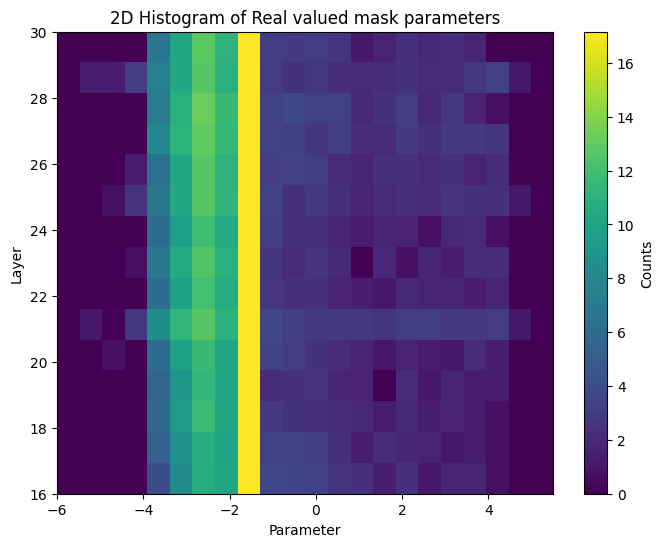

In [12]:

stacked_weights = []
for l in config.specs.target_layers:
    stacked_weights.append(layer_weights[f"model.layers.{l}.self_attn.mask_qkv_proj"].float().cpu().numpy().flatten())
stacked_weights = np.stack(stacked_weights)
l = config.specs.target_layers[0]
L = config.specs.target_layers[-1]
m = np.floor(stacked_weights.min())
M = np.ceil(stacked_weights.max())+0.5
bins = np.arange(m,M, 0.5)
hist_matrix = np.zeros((stacked_weights.shape[0], len(bins)-1))

for i, arr in enumerate(stacked_weights):
    counts, _ = np.histogram(arr, bins=bins)
    counts[counts==0] = 1
    hist_matrix[i, :] = np.log(counts)
# Plot the 2D histogram as a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(hist_matrix, aspect='auto', cmap='viridis', extent=[m, M, l, L]) 
plt.colorbar(label='Counts')
plt.xlabel('Parameter')
plt.ylabel('Layer')
plt.title('2D Histogram of Real valued mask parameters')

## K,Q,V densities

In [13]:
num_heads = model_config.num_attention_heads
head_dim = model_config.hidden_size // num_heads 
num_key_value_heads = model_config.num_key_value_heads
hidden_size = model_config.hidden_size
query_pos = num_heads * head_dim
op_size = num_heads * head_dim + 2 * (num_key_value_heads * head_dim)


In [86]:
coordinates = []
for layer_name, weights in layer_weights.items():
    if "mask_qkv_proj" in layer_name:
        mask = get_mask(weights, config.specs.tau, False, binary=True)
        value_states = mask[query_pos + num_key_value_heads * head_dim:, ...]
        coordinates.append(value_states.nonzero().cpu())

In [88]:
fig = go.Figure()
l = config.specs.target_layers[0]
colormap = cm.get_cmap('viridis', len(coordinates))
# Loop over each set of coordinates
for i in range(len(coordinates)):
    fig.add_trace(go.Scatter(
        x=coordinates[i][:,1],  # Second column for x
        y=coordinates[i][:,0],  # First column for y
        mode='markers',
        marker=dict(
            size=5,
            color=colormap(i)  # Custom color for each trace
        ),
        name=f'Layer {l+i}'
    ))

# Update layout for better visual clarity
fig.update_layout(
    title="Scatter Plot of Value masked Value parameters",

    height=800,
    width=1200,
    xaxis=dict(title="Output Dimension", range=[0, 3072]),  # X-axis range fixed to [0, 800]
    yaxis=dict(title="Input Dimension", range=[0, 3072]),
    showlegend=True
)

# Display the plot
fig.show()

/tmp/ipykernel_3727379/3870256193.py:3: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



In [16]:
coordinates = []
for layer_name, weights in layer_weights.items():
    if "mask_o_proj" in layer_name:
        mask = get_mask(weights, config.specs.tau, False, binary=True)
        coordinates.append(mask.nonzero().cpu())
        
fig = go.Figure()
l = config.specs.target_layers[0]
# Loop over each set of coordinates
for i in range(len(coordinates)):
    fig.add_trace(go.Scatter(
        x=coordinates[i][:,1],  # Second column for x
        y=coordinates[i][:,0],  # First column for y
        mode='markers',
        marker=dict(
            size=5,
            color=colormap(i)  # Custom color for each trace
        ),
        name=f'Layer {l+i}'
    ))

# Update layout for better visual clarity
fig.update_layout(
    title="Scatter Plot of Value mask o_proj parameters",

    height=800,
    width=1200,
    xaxis=dict(title="Output Dimension", range=[0, 3072]),  # X-axis range fixed to [0, 800]
    yaxis=dict(title="Input Dimension", range=[0, 3072]),
    showlegend=True
)

# Display the plot

## Comparing the activations

In [17]:
seed = config.seed
dataset_folders = [os.path.join(__DIR__, f) for f in config.specs.datasets.files]

dataset = load_from_disk(dataset_folders[0])
dataset = dataset.train_test_split(test_size=config.test_size, seed=seed) 
for d_f in dataset_folders[1:]:
    ds = load_from_disk(d_f)
    ds = ds.train_test_split(test_size=config.test_size, seed=seed)
    dataset["train"] = concatenate_datasets([dataset["train"],ds["train"]])
    dataset["test"] = concatenate_datasets([dataset["test"],ds["test"]])

In [18]:

def hook_fn(array):    
    def mlp_hook(module, input, output):
        """
        Hook function to capture and store the attention weights from the module.
        It assumes the output of the attention module contains the softmaxed attention weights.
        """
        array.append(output)
    return mlp_hook

In [19]:
for l in config.specs.target_layers:
    model.model.layers._modules[str(l)].self_attn.mask_enabled = False
    model.model.layers._modules[str(l)].mlp.mask_enabled = False
mlp_activations = []
roles = []
with torch.no_grad():
    for d in tqdm(dataset["test"]):
        handles = []
        array = []
        for i in range(32):
            handles.append(model.model.layers._modules[str(i)].mlp.register_forward_hook(hook_fn(array)))
        messages = [{"role": "user", "content": d["user"]}]
        tokenized = tokenizer.apply_chat_template(messages, tokenize=True, return_tensors="pt", add_generation_prompt=True, padding=True, return_dict=True)
        input_ids = tokenized["input_ids"].to(model.device)
        attn_mask = tokenized["attention_mask"].to(model.device)
        output = model(input_ids=input_ids, attention_mask=attn_mask, output_attentions=False)
        mlp_activations.append(torch.stack(array)[:,0,-1,:].detach().cpu())
        roles.append(d["role"])
        for handle in handles:
            handle.remove()
stacked_activations = torch.stack(mlp_activations).float()
stacked_activations.shape

100%|██████████| 833/833 [00:54<00:00, 15.31it/s]


torch.Size([833, 32, 3072])

In [20]:
for l in config.specs.target_layers:
    model.model.layers._modules[str(l)].self_attn.mask_enabled = True
    model.model.layers._modules[str(l)].mlp.mask_enabled = True
mlp_activations = []
roles = []
with torch.no_grad():
    for d in tqdm(dataset["test"]):
        handles = []
        array = []
        for i in range(32):
            handles.append(model.model.layers._modules[str(i)].mlp.register_forward_hook(hook_fn(array)))
        messages = [{"role": "user", "content": d["user"]}]
        tokenized = tokenizer.apply_chat_template(messages, tokenize=True, return_tensors="pt", add_generation_prompt=True, padding=True, return_dict=True)
        input_ids = tokenized["input_ids"].to(model.device)
        attn_mask = tokenized["attention_mask"].to(model.device)
        output = model(input_ids=input_ids, attention_mask=attn_mask, output_attentions=False)
        mlp_activations.append(torch.stack(array)[:,0,-1,:].detach().cpu())
        roles.append(d["role"])
        for handle in handles:
            handle.remove()
stacked_activations2 = torch.stack(mlp_activations).float()
stacked_activations2.shape

100%|██████████| 833/833 [02:00<00:00,  6.90it/s]


torch.Size([833, 32, 3072])

In [21]:
(U, S, V) = torch.pca_lowrank(stacked_activations[:,16:-1,:].view(833,-1), center=True)

In [22]:
pca_ = torch.matmul(stacked_activations[:,16:-1,:].view(833,-1), V[:, :3])

In [23]:
pca_2 = torch.matmul(stacked_activations2[:,16:-1,:].view(833,-1), V[:, :3])

In [24]:
means = []
for layer_name, weights in layer_weights.items():
    if "mask_qkv_proj" in layer_name:
        mask = get_mask(weights, config.specs.tau, False, binary=True)
        value_states = mask[query_pos + num_key_value_heads * head_dim :, ...]
        means.append(value_states.float().sum(dim=1).cpu())

projected = torch.matmul(torch.cat(means, dim=0), V[:, :3])
projected = torch.arange(1, 500,1).view(-1,1)*projected.view(1,-1)

In [26]:
for handle in handles:
            handle.remove()

In [58]:
import random
def file_to_string(filename):
    with open(filename, 'r') as file:
        return file.read()
EUREKA_ROOT_DIR="../head_ablations/"

prompt_dir = f'../head_ablations/prompts/'
initial_system = file_to_string(f'{prompt_dir}/initial_system.txt')
code_output_tip = file_to_string(f'{prompt_dir}/code_output_tip.txt')
initial_user = file_to_string(f'{prompt_dir}/initial_user.txt')
reward_signature = file_to_string(f'{prompt_dir}/reward_signature.txt')

tasks = {"acrobot":"to apply torques on the actuated joint to swing the free end of the linear chain above a given height from an initial state hanging downwards",
         "cartpolev1" : "to balance a pole on a cart so that the pole stays between +/- 0.209 away from the vertical",
        "cartpolev2" : "to balance a pole on a cart so that the pole stays between [0,0.21] away from the vertical",
        "orbit_discrete": "to accelerate the space shuttle to orbit the earth counter clockwise between the 2 specified bounds",
        "mountain_car": "The goal is to strategically accelerate the car to reach the goal state on top of the right hill."}

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
assistant_idx = 32001
def get_messages(task, description):
    env_name = task.replace("v1", "").replace("v2", "")
    if f'{env_name}.py' in os.listdir(f'{EUREKA_ROOT_DIR}/envs/classic_control'):
        env_parent = 'classic_control'  
    elif f'{env_name}.py' in os.listdir(f'{EUREKA_ROOT_DIR}/envs/augmented') :
        env_parent = 'augmented'
    elif f'{env_name}.py' in os.listdir(f'{EUREKA_ROOT_DIR}/envs/designed') :
        env_parent = 'designed'
    else : raise ValueError(f"Environment {env_name} not found in classic_control, designed or augmented directories!")
    task_obs_file = f'{EUREKA_ROOT_DIR}/envs/{env_parent}/{env_name}_obs.py'
    task_obs_code_string  = file_to_string(task_obs_file)
    
    system = initial_system.format(task_reward_signature_string=reward_signature)
    user = initial_user.format(task_obs_code_string=task_obs_code_string, task_description=description)
    return system, user

mlp_activations = []
for l in config.specs.target_layers:
    model.model.layers._modules[str(l)].self_attn.mask_enabled = True
    model.model.layers._modules[str(l)].mlp.mask_enabled = True
with torch.no_grad():
    for task, description in tqdm(tasks.items()):

        system, user = get_messages(task, description)

        handles = []
        array = []
        for i in range(32):
            handles.append(model.model.layers._modules[str(i)].mlp.register_forward_hook(hook_fn(array)))
        messages = [
        {
            "role": "system",
            "content": system,
        },
        {"role": "user", "content": user},
        ]
        tokenized = tokenizer.apply_chat_template(messages, tokenize=True, return_tensors="pt", add_generation_prompt=True, padding=True, return_dict=True)
        input_ids = tokenized["input_ids"].to(model.device)
        attn_mask = tokenized["attention_mask"].to(model.device)
        output = model(input_ids=input_ids, attention_mask=attn_mask, output_attentions=False)
        mlp_activations.append(torch.stack(array)[:,0,-1,:].detach().cpu())
        for handle in handles:
            handle.remove()
stacked_activations3 = torch.stack(mlp_activations).float()
stacked_activations3.shape


100%|██████████| 5/5 [00:00<00:00,  6.22it/s]


torch.Size([5, 32, 3072])

In [56]:
pca_3 = torch.matmul(stacked_activations3[:,16:-1,:].view(5,-1), V[:, :3])

In [59]:
pca_4 = torch.matmul(stacked_activations3[:,16:-1,:].view(5,-1), V[:, :3])

In [62]:
import plotly.graph_objects as go

categorical_values = pd.factorize(roles)

color_values = categorical_values[0]

# Create 3D scatter plot with color mapping
pca_data = go.Scatter3d(
    x=pca_[:, 0].cpu().numpy(),
    y=pca_[:, 1].cpu().numpy(),
    z=pca_[:, 2].cpu().numpy(),
    mode='markers',
    marker=dict(
        size=5,
        color=color_values,        # Set color based on color values
        colorscale='Viridis',      # Choose a colorscale, e.g., 'Viridis', 'Cividis', etc.
        colorbar=dict(title='Color')
    )
)

pca_data2 = go.Scatter3d(
    x=pca_2[:, 0].cpu().numpy(),
    y=pca_2[:, 1].cpu().numpy(),
    z=pca_2[:, 2].cpu().numpy(),
    mode='markers',
    marker=dict(
        size=5,
        color=color_values+0.5,        # Set color based on color values
    )
)

pca_data3 = go.Scatter3d(
    x=pca_3[:, 0].cpu().numpy(),
    y=pca_3[:, 1].cpu().numpy(),
    z=pca_3[:, 2].cpu().numpy(),
    mode='markers',
    marker=dict(
        size=5,
        color="red",        # Set color based on color values
    )
)

pca_data4 = go.Scatter3d(
    x=pca_4[:, 0].cpu().numpy(),
    y=pca_4[:, 1].cpu().numpy(),
    z=pca_4[:, 2].cpu().numpy(),
    mode='markers',
    marker=dict(
        size=5,
        color="black",        # Set color based on color values
    )
)

# projected = go.Scatter3d(
#     x=projected[:,0].cpu().numpy(),
#     y=projected[:,1].cpu().numpy(),
#     z=projected[:,2].cpu().numpy(),
#     mode='markers',
#     marker=dict(
#         size=6,
#         color="red",        # Set color based on color values
#     )
# )
fig = go.Figure(data=[pca_data, pca_data2, pca_data3, pca_data4])

# Update layout for better visualization
fig.update_layout(scene=dict(
    xaxis_title='X Axis',
    yaxis_title='Y Axis',
    zaxis_title='Z Axis'
))

fig.show()